In [1]:
import ast
import io
from pathlib import Path

import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Academic paper style: clean whitegrid, serif fonts, muted palette.
sns.set_theme(style="whitegrid", context="paper", font_scale=1.15)
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "axes.titleweight": "bold",
    "axes.edgecolor": "0.3",
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
    "legend.frameon": False,
})

FIG_DIR = Path("report/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Text width of a two-column paper (\textwidth for figure*/table*), in inches.
PAGE_W = 7.0
COL_W = 3.35

# Consistent colors: HRM-Text is the accent, baselines are muted greys/blues.
ACCENT = "#c0392b"        # HRM-Text, direct
ACCENT_LIGHT = "#e07b6f"  # HRM-Text, Meta-ICL
MUTED = "#7f8c8d"         # LLM baseline, direct
MUTED_LIGHT = "#b9c0c4"   # LLM baseline, Meta-ICL
TRM_COLOR = "#2c6fbb"     # TRM comparison


def save_fig(fig, name):
    """Export a figure as both vector PDF and raster PNG for the paper."""
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}")
    return fig


HRM_ARCH = "HRM-Text-1B"

# Short display names keyed by the HuggingFace id found in the run's `model` config.
ARCH_LABELS = {
    "sapientinc/HRM-Text-1B": HRM_ARCH,
    "mistralai/Mistral-7B-v0.3": "Mistral-7B",
    "Qwen/Qwen3-4B": "Qwen3-4B",
    "Qwen/Qwen2.5-3B": "Qwen2.5-3B",
    "HuggingFaceTB/SmolLM2-1.7B": "SmolLM2-1.7B",
    "Qwen/Qwen2.5-1.5B": "Qwen2.5-1.5B",
    "meta-llama/Llama-3.2-1B": "Llama-3.2-1B",
    "google/gemma-3-1b-pt": "Gemma-3-1B",
    "Qwen/Qwen3-0.6B": "Qwen3-0.6B",
}

DIRECT, META_ICL = "Standard SFT", "Meta-ICL"

# The 11 GraphQA reasoning tasks (column suffixes in the performance data).
GRAPH_TASKS = [
    "ConnectedNodes", "CycleCheck", "DisconnectedNodes", "EdgeCount",
    "EdgeExistence", "MaximumFlow", "NodeCount", "NodeDegree",
    "Reachability", "ShortestPath", "TriangleCounting",
]

# Compact task headers so an 11-column heatmap/table fits the page width.
TASK_ABBREV = {
    "ConnectedNodes": "ConnNod", "CycleCheck": "Cycle",
    "DisconnectedNodes": "DisconnNod", "EdgeCount": "EdgeCnt",
    "EdgeExistence": "EdgeExist", "MaximumFlow": "MaxFlow",
    "NodeCount": "NodeCnt", "NodeDegree": "NodeDeg",
    "Reachability": "Reach", "ShortestPath": "ShortPath",
    "TriangleCounting": "TriCount",
}


In [2]:
# The ablation W&B export wraps each row in an extra layer of quotes (doubled inner
# quotes), so a plain read_csv collapses everything into one column. Unwrap it first.
def read_wandb_csv(path):
    lines = [ln for ln in Path(path).read_text().splitlines() if ln]
    unwrapped = [
        ln[1:-1].replace('""', '"') if ln.startswith('"') and ln.endswith('"') else ln
        for ln in lines
    ]
    return pd.read_csv(io.StringIO("\n".join(unwrapped)))


ablation_data = read_wandb_csv("data/results/ablation_data.csv")

# The v2 exports are plain CSVs, one file per (model family, evaluation split). Column
# *order* differs between families, so concat aligns on names and NaN-fills the rest.
V2_DIR = Path("data/results/v2")
V2_FAMILIES = ["baseline", "meta-icl", "hrm", "hrm-meta-icl"]


def load_v2(split):
    return pd.concat(
        [pd.read_csv(V2_DIR / f"{fam}-{split}.csv") for fam in V2_FAMILIES],
        ignore_index=True,
    )


performance_data = load_v2("id")
# Leave-one-task-out OOD: one run per held-out task, per model.
ood_data = load_v2("ood")

print(f"ID runs: {len(performance_data)}   OOD runs: {len(ood_data)}")


ID runs: 18   OOD runs: 198


In [3]:
performance_data[["Name", "State", "config_name", "val/exact_match"]].head(4)


,Name,State,config_name,val/exact_match
0,baseline-1b-mistral-7b-v0.3-id,finished,baseline_1b,0.545455
1,baseline-1b-qwen3-4b-id,finished,baseline_1b,0.722078
2,baseline-1b-qwen2.5-3b-id,finished,baseline_1b,0.716883
3,baseline-1b-gemma-3-1b-pt-id,finished,baseline_1b,0.654545


In [4]:
ablation_data.head(2)

,Name,State,Notes,User,Tags,Created,Runtime,Sweep,H_cycles,L_cycles,ckpt_path,data,max_generation,ratio_L_over_H,use_ema,eval/accuracy,eval/correct,eval/n
0,graphqa_trm_H1_L12,finished,-,NaN,"H1, L12, ablation, trm",2026-08-03T08:21:23.000Z,7,NaN,1,12,/lustre/fsn1/projects/rech/axa/ugs28gz/graphqa...,data/graphqa/hrm-text/standard/test.jsonl,32,12.0,True,0.509091,196.0,385.0
1,graphqa_H1_L12,finished,-,NaN,"H1, L12, ablation",2026-08-03T07:56:16.000Z,9,NaN,1,12,/lustre/fsn1/projects/rech/axa/ugs28gz/graphqa...,data/graphqa/hrm-text/standard/test.jsonl,32,12.0,True,0.514286,198.0,385.0


# RQ1 — Performance: HRM-Text vs. baselines

Exact-match accuracy on GraphQA over **9 architectures × 2 training regimes** (18 runs):
HRM-Text-1B plus 8 open-weight LLM backbones (Mistral-7B, Qwen3-4B, Qwen2.5-3B,
SmolLM2-1.7B, Qwen2.5-1.5B, Llama-3.2-1B, Gemma-3-1B, Qwen3-0.6B), each trained
either **directly** or with **Meta-ICL**.

In-distribution (`standard`) results use all 11 tasks. Out-of-distribution generalization is
measured **leave-one-task-out**: each GraphQA task is held out in turn and the model
evaluated on that unseen task; the reported OOD number is the mean over the 11 held-out runs.

> **Caption note:** the ID and OOD panels use *different x-scales*. OOD accuracy is roughly
> an order of magnitude lower than ID, so a shared 0–1 axis would flatten every OOD bar.


In [5]:
# `dataset` and `model` are dict-strings holding the run config. The W&B run `Name`
# is NOT unique (both HRM variants export as "hrm-text-id"), so every key below is
# derived from (architecture, regime) instead.
def enrich(df):
    out = df.copy()
    dataset = out["dataset"].map(ast.literal_eval)
    out["test_type"] = dataset.map(lambda d: d["test_type"])
    out["dataset_config"] = dataset.map(lambda d: d["dataset_config"])
    out["task"] = dataset.map(lambda d: d["ood_task"])
    out["arch"] = out["model"].map(lambda s: ARCH_LABELS[ast.literal_eval(s)["name"]])
    out["regime"] = np.where(out["dataset_config"] == "meta-icl", META_ICL, DIRECT)
    out["model"] = np.where(
        out["regime"] == META_ICL, out["arch"] + f" ({META_ICL})", out["arch"]
    )
    out["exact_match"] = out["val/exact_match"].astype(float)
    return out


perf_id = (
    enrich(performance_data)
    .sort_values("Created")
    .drop_duplicates(subset=["arch", "regime"], keep="last")
    .reset_index(drop=True)
)

# For OOD runs only the held-out task's column is populated, so `val/exact_match`
# already is that task's score.
ood = (
    enrich(ood_data)
    .sort_values("Created")
    .drop_duplicates(subset=["arch", "regime", "task"], keep="last")
    .reset_index(drop=True)
)

# One shared ordering: architectures ranked by direct-regime ID accuracy, HRM-Text
# pinned first; rows are then grouped into a Direct block and a Meta-ICL block.
_direct_rank = (
    perf_id[perf_id["regime"] == DIRECT]
    .set_index("arch")["exact_match"]
    .sort_values(ascending=False)
)
ARCH_ORDER = [HRM_ARCH] + [a for a in _direct_rank.index if a != HRM_ARCH]
MODEL_ORDER = ARCH_ORDER + [f"{a} ({META_ICL})" for a in ARCH_ORDER]

perf_id["model"] = pd.Categorical(perf_id["model"], MODEL_ORDER, ordered=True)
perf_id = perf_id.sort_values("model").reset_index(drop=True)

# Models x held-out-task matrix (canonical task order) + mean OOD per model.
ood_by_task = (
    ood.pivot(index="model", columns="task", values="exact_match")
    .reindex(index=MODEL_ORDER, columns=GRAPH_TASKS)
)
# Models x task matrix for the in-distribution runs.
id_by_task = perf_id.set_index("model")[[f"val/exact_match_{t}" for t in GRAPH_TASKS]]
id_by_task.columns = GRAPH_TASKS
id_by_task = id_by_task.reindex(MODEL_ORDER)

overall_id = perf_id.set_index("model")["exact_match"].reindex(MODEL_ORDER)
overall_ood = ood_by_task.mean(axis=1)

assert len(perf_id) == 18 and ood_by_task.notna().all().all(), "unexpected v2 coverage"
pd.DataFrame({"ID": overall_id, "OOD (mean)": overall_ood}).round(3)


,ID,OOD (mean)
model,,
HRM-Text-1B,0.831,0.407
Qwen3-0.6B,0.725,0.133
Qwen3-4B,0.722,0.279
Qwen2.5-3B,0.717,0.120
Qwen2.5-1.5B,0.701,0.092
SmolLM2-1.7B,0.686,0.141
Gemma-3-1B,0.655,0.065
Llama-3.2-1B,0.629,0.080
Mistral-7B,0.545,0.057


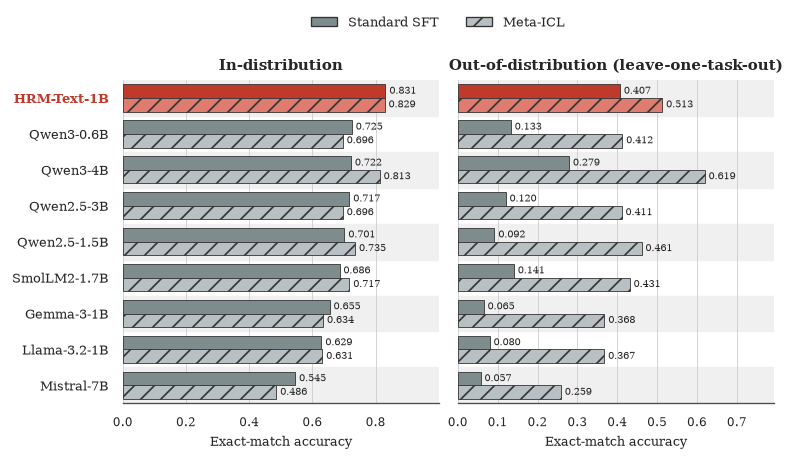

In [6]:
# Main RQ1 figure (full-width `figure*`): one row per architecture, paired bars for the
# Direct and Meta-ICL regimes. ID and OOD sit in separate panels because OOD accuracy is
# an order of magnitude smaller and would be invisible on a shared 0-1 axis.
def plot_id_ood_panels(fname="perf_overall_id_ood"):
    y = np.arange(len(ARCH_ORDER))
    h = 0.38
    fig, axes = plt.subplots(
        1, 2, figsize=(PAGE_W, 3.5), sharey=True, gridspec_kw={"wspace": 0.06}
    )

    panels = [
        (axes[0], overall_id, "In-distribution", (0, 1.0)),
        (axes[1], overall_ood, "Out-of-distribution (leave-one-task-out)", None),
    ]
    for ax, series, title, xlim in panels:
        for i in range(0, len(ARCH_ORDER), 2):
            ax.axhspan(i - 0.5, i + 0.5, color="0.94", zorder=0)

        direct = np.array([series.get(a, np.nan) for a in ARCH_ORDER], dtype=float)
        meta = np.array(
            [series.get(f"{a} ({META_ICL})", np.nan) for a in ARCH_ORDER], dtype=float
        )
        is_hrm = [a == HRM_ARCH for a in ARCH_ORDER]

        groups = [
            (y - h / 2, direct, [ACCENT if k else MUTED for k in is_hrm], None),
            (y + h / 2, meta, [ACCENT_LIGHT if k else MUTED_LIGHT for k in is_hrm], "//"),
        ]
        top = np.nanmax(np.concatenate([direct, meta]))
        hi = xlim[1] if xlim else top * 1.28
        for ypos, vals, colors, hatch in groups:
            bars = ax.barh(ypos, np.nan_to_num(vals), height=h, color=colors,
                           edgecolor="0.2", linewidth=0.5, hatch=hatch, zorder=2)
            for bar, v in zip(bars, vals):
                ax.text(v + hi * 0.012, bar.get_y() + bar.get_height() / 2,
                        f"{v:.3f}", va="center", ha="left", fontsize=6, zorder=3)

        ax.set_xlim(0, hi)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("Exact-match accuracy", fontsize=8)
        ax.tick_params(axis="x", labelsize=7)
        ax.grid(axis="y", visible=False)
        ax.set_axisbelow(True)

    # Drop the left panel's final tick so it does not collide with the right panel's 0.0.
    axes[0].set_xticks(np.arange(0, 1.0, 0.2))
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(ARCH_ORDER, fontsize=8)
    axes[0].set_ylim(len(ARCH_ORDER) - 0.5, -0.5)  # best architecture on top
    for lbl, hrm in zip(axes[0].get_yticklabels(), [a == HRM_ARCH for a in ARCH_ORDER]):
        if hrm:
            lbl.set_color(ACCENT)
            lbl.set_fontweight("bold")

    handles = [
        mpl.patches.Patch(facecolor=MUTED, edgecolor="0.2", label=DIRECT),
        mpl.patches.Patch(facecolor=MUTED_LIGHT, edgecolor="0.2", hatch="//", label=META_ICL),
    ]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.06),
               ncol=2, fontsize=8, frameon=False)
    sns.despine(fig=fig, left=True)
    save_fig(fig, fname)
    plt.show()


plot_id_ood_panels()


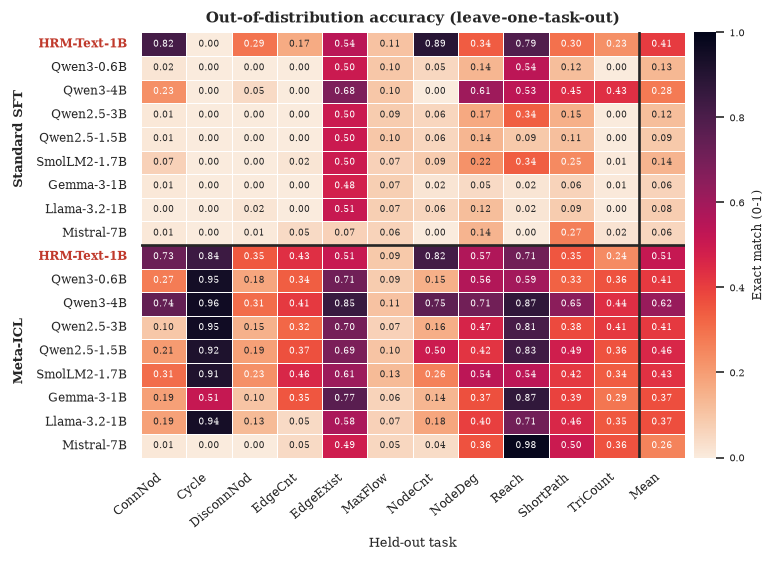

In [7]:
# Full-width per-task heatmap: 18 rows (9 architectures x 2 regimes) split into a Direct
# block and a Meta-ICL block, so a row label only needs the architecture name.
def plot_task_heatmap(mat, title, fname, vmax, xlabel=""):
    block = len(ARCH_ORDER)
    annotated = mat.copy()
    annotated["Mean"] = mat.mean(axis=1)

    fig, ax = plt.subplots(figsize=(PAGE_W, 4.6))
    sns.heatmap(
        annotated, annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=vmax,
        linewidths=0.4, linecolor="white", annot_kws={"fontsize": 5.5},
        cbar_kws={"label": f"Exact match (0-{vmax:g})", "pad": 0.015}, ax=ax,
    )
    ax.axhline(block, color="0.15", linewidth=1.6)          # regime separator
    ax.axvline(len(GRAPH_TASKS), color="0.15", linewidth=1.6)  # Mean separator

    ax.set_xticklabels([TASK_ABBREV.get(c, c) for c in annotated.columns],
                       rotation=40, ha="right", fontsize=7)
    ax.set_yticklabels([str(m).replace(f" ({META_ICL})", "") for m in mat.index],
                       rotation=0, fontsize=7)
    for lbl in ax.get_yticklabels():
        if lbl.get_text() == HRM_ARCH:
            lbl.set_color(ACCENT)
            lbl.set_fontweight("bold")

    # Label each regime block once, clear of the architecture tick labels.
    for i, name in enumerate([DIRECT, META_ICL]):
        ax.text(-0.225, (i + 0.5) * block, name, transform=ax.get_yaxis_transform(),
                rotation=90, va="center", ha="center", fontsize=8, fontweight="bold")

    ax.set_ylabel("")
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.figure.axes[-1].yaxis.label.set_size(7)
    ax.figure.axes[-1].tick_params(labelsize=6)
    save_fig(fig, fname)
    plt.show()


# OOD accuracy is far below 1.0 on most cells, so derive the color cap from the data.
ood_vmax = np.ceil(ood_by_task.to_numpy().max() * 10) / 10
plot_task_heatmap(
    ood_by_task,
    "Out-of-distribution accuracy (leave-one-task-out)",
    "perf_ood_by_task",
    vmax=ood_vmax,
    xlabel="Held-out task",
)


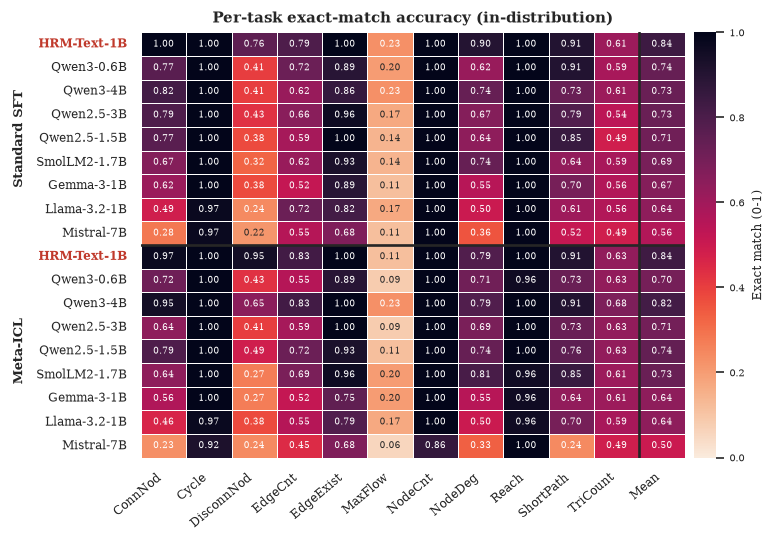

In [8]:
plot_task_heatmap(
    id_by_task,
    "Per-task exact-match accuracy (in-distribution)",
    "perf_by_task",
    vmax=1.0,
)


In [9]:
# Single full-width `table*`: models as rows (Direct / Meta-ICL blocks), the 11 tasks plus
# a Mean as column groups, each split into an ID and an OOD sub-column.
def combined_task_table_latex(id_mat, ood_mat, caption, label):
    def with_mean(mat):
        out = mat.copy()
        out["Mean"] = mat.mean(axis=1)
        return out

    idm, oodm = with_mean(id_mat), with_mean(ood_mat)
    groups = [TASK_ABBREV.get(c, c) for c in idm.columns]
    tbl = pd.concat(
        {g: pd.DataFrame({"ID": idm[c], "OOD": oodm[c]})
         for g, c in zip(groups, idm.columns)},
        axis=1,
    ).reindex(columns=pd.MultiIndex.from_product([groups, ["ID", "OOD"]]))
    tbl.index = [str(m).replace(f" ({META_ICL})", "") for m in id_mat.index]

    # Drop the leading zero (".84") so 24 numeric columns still fit the text width.
    def fmt(v):
        return f"{v:.2f}".lstrip("0") if v < 1 else f"{v:.2f}"

    lines = tbl.to_latex(
        float_format=fmt,
        column_format="l|" + "cc|" * (len(groups) - 1) + "cc",
        escape=False, na_rep="--", multicolumn=True, multicolumn_format="c",
    ).splitlines()

    ncol = 1 + 2 * len(groups)
    block = len(ARCH_ORDER)
    head = lines.index(r"\midrule")
    rows = lines[head + 1: head + 1 + 2 * block]
    for i in (0, block):  # HRM-Text is pinned first in each block
        rows[i] = rows[i].replace(HRM_ARCH, rf"\textbf{{{HRM_ARCH}}}", 1)

    cmid = " ".join(
        rf"\cmidrule(lr){{{2 + 2 * j}-{3 + 2 * j}}}" for j in range(len(groups))
    )

    def banner(name):
        return rf"\multicolumn{{{ncol}}}{{l}}{{\textit{{{name}}}}} \\"

    top = lines.index(r"\toprule")
    body = (
        lines[: top + 2] + [cmid] + lines[top + 2: head + 1]
        + [banner(DIRECT)] + rows[:block]
        + [r"\midrule", banner(META_ICL)] + rows[block:]
        + lines[head + 1 + 2 * block:]
    )
    return "\n".join([
        r"\begin{table*}[t]", r"\centering", r"\small",
        rf"\caption{{{caption}}}", rf"\label{{{label}}}",
        r"\resizebox{\textwidth}{!}{%",
        *body,
        r"}",
        r"\end{table*}",
    ])


print(combined_task_table_latex(
    id_by_task,
    ood_by_task,
    "GraphQA exact-match accuracy per task. \\textbf{ID}: in-distribution. "
    "\\textbf{OOD}: leave-one-task-out, i.e.\\ the task was held out of training. "
    "Leading zeros omitted.",
    "tab:perf_by_task",
))


\begin{table*}[t]
\centering
\small
\caption{GraphQA exact-match accuracy per task. \textbf{ID}: in-distribution. \textbf{OOD}: leave-one-task-out, i.e.\ the task was held out of training. Leading zeros omitted.}
\label{tab:perf_by_task}
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|cc|cc|cc|cc|cc|cc|cc|cc|cc|cc|cc|cc}
\toprule
 & \multicolumn{2}{c}{ConnNod} & \multicolumn{2}{c}{Cycle} & \multicolumn{2}{c}{DisconnNod} & \multicolumn{2}{c}{EdgeCnt} & \multicolumn{2}{c}{EdgeExist} & \multicolumn{2}{c}{MaxFlow} & \multicolumn{2}{c}{NodeCnt} & \multicolumn{2}{c}{NodeDeg} & \multicolumn{2}{c}{Reach} & \multicolumn{2}{c}{ShortPath} & \multicolumn{2}{c}{TriCount} & \multicolumn{2}{c}{Mean} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9} \cmidrule(lr){10-11} \cmidrule(lr){12-13} \cmidrule(lr){14-15} \cmidrule(lr){16-17} \cmidrule(lr){18-19} \cmidrule(lr){20-21} \cmidrule(lr){22-23} \cmidrule(lr){24-25}
 & ID & OOD & ID & OOD & ID & OOD & ID & OOD & ID & OOD & ID 

In [14]:
# Compact single-column headline table: 9 architectures x {ID, OOD} x {Direct, Meta-ICL}.
# The old per-task ID/OOD cross-table would have needed 36 numeric columns.
summary = pd.DataFrame(
    {
        ("ID", DIRECT): overall_id.reindex(ARCH_ORDER).to_numpy(),
        ("ID", META_ICL): overall_id.reindex(
            [f"{a} ({META_ICL})" for a in ARCH_ORDER]).to_numpy(),
        ("OOD", DIRECT): overall_ood.reindex(ARCH_ORDER).to_numpy(),
        ("OOD", META_ICL): overall_ood.reindex(
            [f"{a} ({META_ICL})" for a in ARCH_ORDER]).to_numpy(),
    },
    index=ARCH_ORDER,
)
summary.columns = pd.MultiIndex.from_tuples(summary.columns)

summary_lines = summary.round(3).to_latex(
    float_format="{:.3f}".format,
    column_format="l|cc|cc",
    escape=False,
    na_rep="--",
    multicolumn=True,
    multicolumn_format="c",
).splitlines()
head = summary_lines.index(r"\midrule")
summary_lines[head + 1] = summary_lines[head + 1].replace(
    HRM_ARCH, rf"\textbf{{{HRM_ARCH}}}", 1
)

print("\n".join([
    r"\begin{table}[t]", r"\centering", r"\small",
    r"\caption{GraphQA exact-match accuracy. OOD is the mean over the 11 "
    r"leave-one-task-out evaluations.}",
    r"\label{tab:perf_summary}",
    *summary_lines,
    r"\end{table}",
]))

summary.round(3)


\begin{table}[t]
\centering
\small
\caption{GraphQA exact-match accuracy. OOD is the mean over the 11 leave-one-task-out evaluations.}
\label{tab:perf_summary}
\begin{tabular}{l|cc|cc}
\toprule
 & \multicolumn{2}{c}{ID} & \multicolumn{2}{c}{OOD} \\
 & Standard SFT & Meta-ICL & Standard SFT & Meta-ICL \\
\midrule
\textbf{HRM-Text-1B} & 0.831 & 0.829 & 0.407 & 0.513 \\
Qwen3-0.6B & 0.725 & 0.696 & 0.133 & 0.412 \\
Qwen3-4B & 0.722 & 0.813 & 0.279 & 0.619 \\
Qwen2.5-3B & 0.717 & 0.696 & 0.120 & 0.411 \\
Qwen2.5-1.5B & 0.701 & 0.735 & 0.092 & 0.461 \\
SmolLM2-1.7B & 0.686 & 0.717 & 0.141 & 0.431 \\
Gemma-3-1B & 0.655 & 0.634 & 0.065 & 0.368 \\
Llama-3.2-1B & 0.629 & 0.631 & 0.080 & 0.367 \\
Mistral-7B & 0.545 & 0.486 & 0.057 & 0.259 \\
\bottomrule
\end{tabular}
\end{table}


ID                   OOD         
             Standard SFT Meta-ICL Standard SFT Meta-ICL
HRM-Text-1B         0.831    0.829        0.407    0.513
Qwen3-0.6B          0.725    0.696        0.133    0.412
Qwen3-4B            0.722    0.813        0.279    0.619
Qwen2.5-3B          0.717    0.696        0.120    0.411
Qwen2.5-1.5B        0.701    0.735        0.092    0.461
SmolLM2-1.7B        0.686    0.717        0.141    0.431
Gemma-3-1B          0.655    0.634        0.065    0.368
Llama-3.2-1B        0.629    0.631        0.080    0.367
Mistral-7B          0.545    0.486        0.057    0.259

# RQ2 — Ablation: the L/H ratio drives performance

Two effects on GraphQA test accuracy, shown for both HRM and TRM:

1. **The L/H ratio is decisive (axis 2).** Raising the low-level-to-high-level cycle
   ratio $L/H$ improves accuracy, peaking at the largest ratio. For HRM, ratios below 1
   collapse performance entirely, whereas TRM is markedly more robust to the ratio.
2. **Pure recursion at a fixed ratio hurts.** Holding $L/H = 1.5$ fixed and simply scaling
   up the number of recurrent cycles degrades accuracy to zero — for both HRM and TRM.


In [15]:
# Clean ablation runs: drop those without an eval score, recompute the true L/H ratio.
abl = ablation_data.copy()
abl = abl[abl["eval/accuracy"].notna()].copy()
abl["accuracy"] = abl["eval/accuracy"].astype(float)
abl["H"] = abl["H_cycles"].astype(int)
abl["L"] = abl["L_cycles"].astype(int)
abl["ratio"] = abl["L"] / abl["H"]
abl["family"] = np.where(abl["Name"].str.contains("trm"), "TRM", "HRM")

# Average any repeated (family, H, L) runs.
abl = (
    abl.groupby(["family", "H", "L", "ratio"], as_index=False)["accuracy"]
    .mean()
    .sort_values(["family", "ratio"])
)
abl


,family,H,L,ratio,accuracy
6,HRM,6,2,0.333333,0.000000
4,HRM,4,3,0.750000,0.062338
3,HRM,3,4,1.333333,0.400000
1,HRM,2,3,1.500000,0.444156
5,HRM,4,6,1.500000,0.054545
7,HRM,6,9,1.500000,0.000000
8,HRM,8,12,1.500000,0.000000
2,HRM,2,6,3.000000,0.438961
0,HRM,1,12,12.000000,0.514286
15,TRM,6,2,0.333333,0.376623


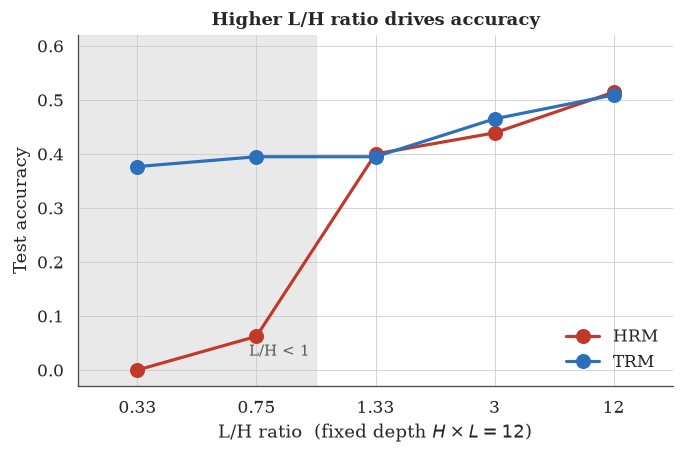

In [16]:
# Axis 2 — ratio effect for HRM and TRM. Hold the total recurrence depth H*L = 12 fixed
# and vary only the L/H ratio. Evenly-spaced x keeps close ratios legible.
def ratio_sweep(family):
    sub = abl[(abl["family"] == family) & (abl["H"] * abl["L"] == 12)]
    return sub.sort_values("ratio").reset_index(drop=True)


hrm_curve = ratio_sweep("HRM")
trm_curve = ratio_sweep("TRM")

# Shared, ordered ratio axis across both families.
ratios = sorted(set(hrm_curve["ratio"]) | set(trm_curve["ratio"]))
pos = {r: i for i, r in enumerate(ratios)}

fig, ax = plt.subplots(figsize=(6.4, 3.8))
n_below = sum(r < 1 for r in ratios)
ax.axvspan(-0.5, n_below - 0.5, color="0.88", alpha=0.7, zorder=0)
ax.text(n_below - 0.55, 0.02, "L/H < 1", fontsize=9, color="0.35", ha="right", va="bottom")

for curve, color, label in [(hrm_curve, ACCENT, "HRM"), (trm_curve, TRM_COLOR, "TRM")]:
    xs = [pos[r] for r in curve["ratio"]]
    ax.plot(xs, curve["accuracy"], marker="o", color=color, markersize=8,
            linewidth=1.9, label=label, zorder=3)

ax.set_xticks(range(len(ratios)))
ax.set_xticklabels([f"{r:.2f}".rstrip("0").rstrip(".") for r in ratios])
ax.set_xlim(-0.5, len(ratios) - 0.5)
ax.set_xlabel("L/H ratio  (fixed depth $H \\times L = 12$)")
ax.set_ylabel("Test accuracy")
ax.set_ylim(-0.03, 0.62)
ax.set_title("Higher L/H ratio drives accuracy")
ax.legend(title="")
sns.despine(ax=ax)
save_fig(fig, "ablation_ratio")
plt.show()


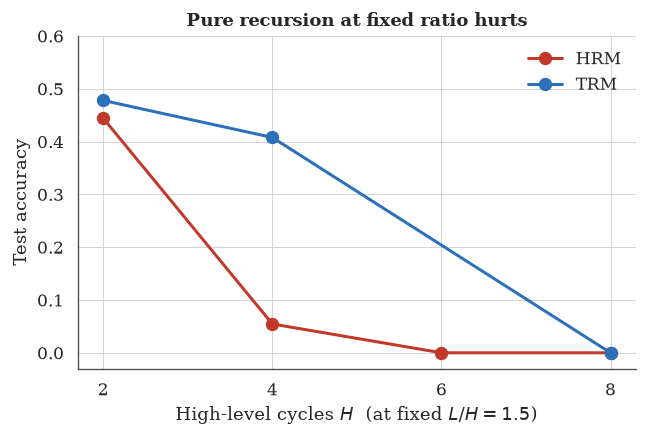

In [17]:
# Fixed-ratio scaling. Hold L/H = 1.5 and increase recurrence depth (H) for HRM and TRM.
fixed = abl[np.isclose(abl["ratio"], 1.5)].sort_values(["family", "H"])

fig, ax = plt.subplots(figsize=(6.0, 3.6))
for fam, color in [("HRM", ACCENT), ("TRM", TRM_COLOR)]:
    sub = fixed[fixed["family"] == fam]
    ax.plot(sub["H"], sub["accuracy"], marker="o", markersize=7, linewidth=1.8,
            color=color, label=fam)

ax.set_xlabel("High-level cycles $H$  (at fixed $L/H = 1.5$)")
ax.set_ylabel("Test accuracy")
ax.set_ylim(-0.03, 0.6)
ax.set_xticks(sorted(fixed["H"].unique()))
ax.set_title("Pure recursion at fixed ratio hurts")
ax.legend(title="")
sns.despine(ax=ax)
save_fig(fig, "ablation_fixed_ratio")
plt.show()
